<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Hcktn_R_(rf_lg).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & IMPORT LIBRARIES
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("🔑 Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')


🔑 Step 1: Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
# ==========================================
# 2. LOCATE YOUR PREPROCESSED SUPER-DATASET
# ==========================================
print("\n🔍 Step 2: Locating the preprocessed Super-Dataset...")
search_pattern = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f"🎯 SUCCESS! Loaded super-dataset from: {file_path}")
else:
    raise FileNotFoundError("❌ ERROR: Could not find 'super_dataset_C_train.csv' in the shared Drive.")


🔍 Step 2: Locating the preprocessed Super-Dataset...
🎯 SUCCESS! Loaded super-dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv


In [110]:
 #3. CLEAN COLUMN NAMES FOR COMPATIBILITY
# ==========================================
df_super.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_super.columns]
print("🧼 Column headers sanitized for robust model training.")



🧼 Column headers sanitized for robust model training.


In [111]:
# ==========================================
# 4. SPLIT THE DATA
# ==========================================
y_model = df_super['covid_vaccine']
X_model = df_super.drop(columns=['covid_vaccine'])

# 20% validation split, maintaining stratified class balance
X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

In [112]:
#5. TRAIN THE RANDOM FOREST MODEL
# ==========================================
print("\n🌳 Step 4: Training Random Forest Classifier...")

# 'class_weight="balanced"' adjusts weights inversely proportional to class frequencies
# This directly addresses the 2:1 imbalance found in your EDA dashboard!
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # Uses all available processor cores for fast training
)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred = rf_model.predict(X_val)
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]




🌳 Step 4: Training Random Forest Classifier...


In [113]:
# ==========================================
# 6. PRINT PERFORMANCE REPORT
# ==========================================
print("\n================ 📊 RANDOM FOREST EVALUATION REPORT ================ ")
auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"▶️ Random Forest Validation ROC-AUC: {auc_score:.4f}\n")
print("▶️ Classification Performance Metrics:")
print(classification_report(y_val, y_pred, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))



================ 📊 RANDOM FOREST EVALUATION REPORT ================ 
▶️ Random Forest Validation ROC-AUC: 0.8334

▶️ Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.85      0.85      0.85       641
    Vaccinated (1)       0.69      0.68      0.69       311

          accuracy                           0.80       952
         macro avg       0.77      0.77      0.77       952
      weighted avg       0.79      0.80      0.80       952



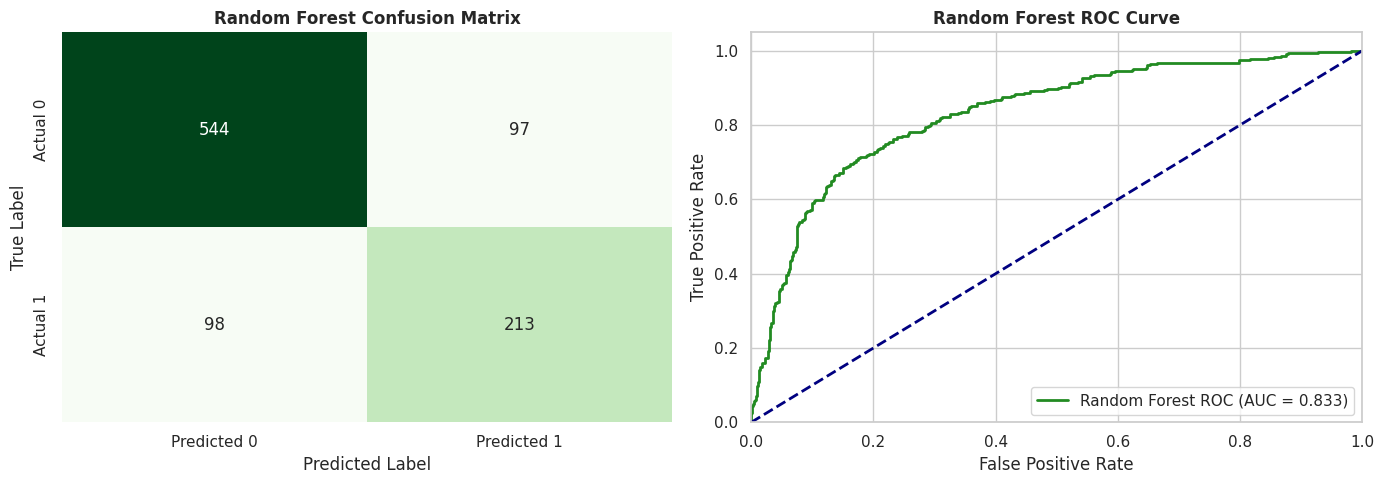


💾 Evaluation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_random_forest_evaluation.png


In [114]:
# ==========================================
# 7. VISUALIZE AND SAVE CHARTS
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='forestgreen', lw=2, label=f'Random Forest ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest ROC Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()

# Save the evaluation dashboard to your shared drive folder
output_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_random_forest_evaluation.png')
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Evaluation charts saved directly to your shared Drive folder at:\n   {output_plot_path}")